In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

In [2]:
# Importing the dependencies
hd = pd.read_csv('C:\ML datasets\BostonHousing.csv')

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\SEPHORA\AppData\Local\Temp\ipykernel_24096\249835366.py:2: SyntaxWarning: invalid escape sequence '\M'
  hd = pd.read_csv('C:\ML datasets\BostonHousing.csv')


In [3]:
hd.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
hd.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
hd.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
price      0
dtype: int64

Finding the relationship or corellation between the data

In [6]:
cor = hd.corr()

<Axes: >

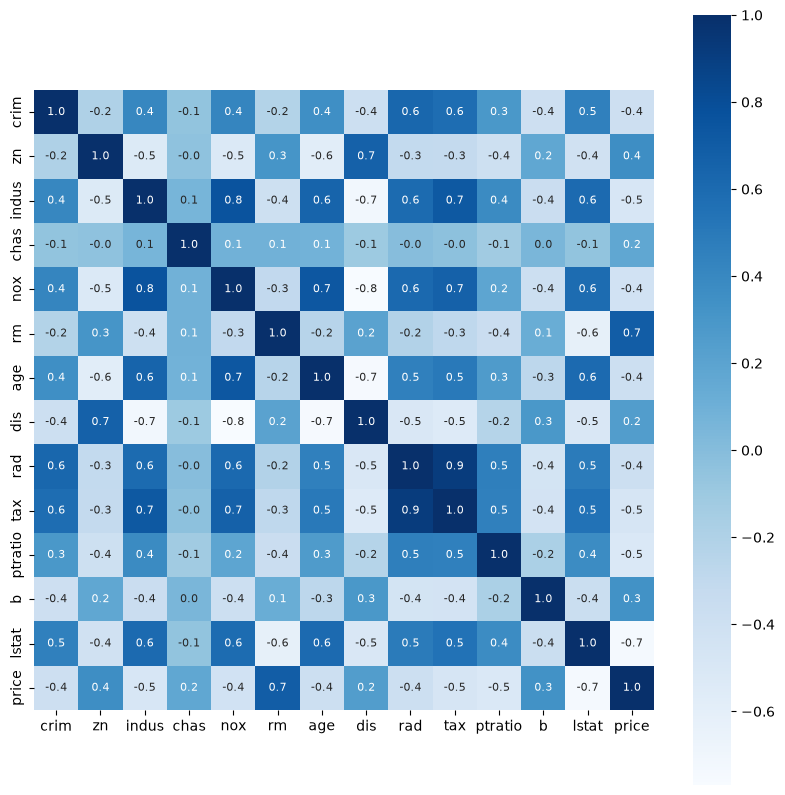

In [7]:
# construting a heatmap to get the corelation
plt.figure(figsize=(10,10))
sns.heatmap(cor,cbar=True,square=True,fmt='.1f',annot=True, annot_kws={'size': 8}, cmap='Blues')

Seperating the variariables

In [8]:
x = hd.drop(['price'], axis=1)
y = hd['price']

In [9]:

# Split the data into training and testing sets (80% for training, 20% for testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training set shape:", (x.shape),(x_train.shape), (y_train.shape))
print("Testing set shape:", (x_test.shape), (y_test.shape))

Training set shape: (506, 13) (404, 13) (404,)
Testing set shape: (102, 13) (102,)


Model Training

In [10]:
# Xgboost 

model = XGBRegressor()


In [11]:
model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evaluation 

In [12]:
tdp = model.predict(x_train)

In [13]:
print("Training set predictions:", tdp)

Training set predictions: [12.003948  19.905811  19.40175   13.407686  18.1968    24.586441
 21.094889  24.700073   8.698919  27.49297   20.713726  36.16758
 31.619846  11.700463  39.804413  13.910057  21.796858  23.697166
 17.603949  24.4048     8.794796  19.179075  25.296047  20.417627
 23.110384  37.894657  15.602701  45.39583   15.703079  22.600576
 14.510424  18.693443  17.792194  16.116182  20.603937  31.594452
 29.094666  15.60457   17.52352   22.50258   19.395124  19.29116
  8.485817  20.60303   16.99622   17.101427  14.496738  49.987614
 14.296039  12.599326  28.686739  21.17694   19.300158  23.097733
 19.103085  24.996561  33.407326   4.9966087 29.595467  18.668325
 21.686403  23.09604   22.802141  20.997677  48.79769   14.603776
 16.60419   27.095928  20.084137  19.803669  20.982637  41.291817
 23.168882  20.386963  18.534784  29.398518  36.38471   24.389822
 11.819747  13.790891  12.2893505 17.795723  33.090008  26.697784
 13.398842  14.389052  50.014202  21.990774  19.8981

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [16]:
score1 = r2_score(y_train, tdp)
score2 = mean_absolute_error(y_train, tdp)

In [21]:
print("r2_score accuracy score: ", score1)
print("mean_absolute_error accuracy score: ", score2)

r2_score accuracy score:  0.9999977822259297
mean_absolute_error accuracy score:  0.009898197532880454


In [23]:
# Accuracy score for the test data
tedp = model.predict(x_test)

In [24]:
score1 = r2_score(y_test, tedp)
score2 = mean_absolute_error(y_test, tedp)

In [25]:
print("r2_score accuracy score: ", score1)
print("mean_absolute_error accuracy score: ", score2)

r2_score accuracy score:  0.8930821357033084
mean_absolute_error accuracy score:  1.9617642056708242


Visuallizing the Predicted and actual prices

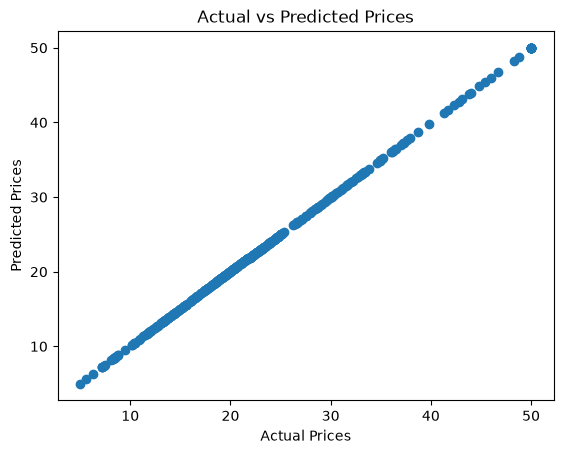

In [28]:
plt.scatter(y_train, tdp)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()